# 04 – Risk Forecasting with DAG & Monte Carlo Simulation

**Project:** AI-Powered Project Planning & Risk Forecasting Platform

This notebook implements **probabilistic schedule forecasting** using a **project-specific Monte Carlo simulation** and a **dependency-aware Directed Acyclic Graph (DAG)** model.

Instead of relying on one generic fixed-duration example, the notebook selects a **real representative high-risk project** from the portfolio dataset, converts it into a task network, and simulates uncertainty at the **task level**.

The workflow allows to:

- select a real project from the historical portfolio
- represent the project as a **DAG of dependent tasks**
- identify the **critical path**
- simulate thousands of completion scenarios with Monte Carlo methods
- generate **P50 and P80 forecasts** and estimate **delay probability**
- compare the project-specific forecast with the existing monitoring snapshot

Key outputs:

- selected project summary
- task dependency graph
- critical path
- simulated completion-time distribution
- P50 / P80 forecast estimates
- probability of schedule delay
- monitoring comparison for the selected project

In [32]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from analytics.metrics import compute_metrics
from modeling.graph_builder import build_project_graph
from modeling.critical_path import critical_path_by_mean
from simulation.monte_carlo import run_monte_carlo
from visualization.charts import dependency_graph_figure

sns.set_style("whitegrid")

## Load Datasets

The `project_portfolio_history.csv` and `risk_monitoring_snapshot.csv` are loaded.

`project_portfolio_history.csv` provides planned and actual project outcomes, while `risk_monitoring_snapshot.csv` provides a forecasting reference point for comparison.


In [33]:
project_df = pd.read_csv(DATA_DIR / "project_portfolio_history.csv")
monitoring_df = pd.read_csv(DATA_DIR / "risk_monitoring_snapshot.csv")

project_df.head()


,Project_ID,Portfolio_Segment,Region,Delivery_Model,Planning_Mode,Complexity_Score,Planned_Duration_Days,Actual_Duration_Days,Delay_Days,Delay_Flag,...,Critical_Path_Task_Count,Vendor_Count,Change_Order_Count,Resource_Buffer_Pct,Weather_Risk_Index,Procurement_Risk_Index,Stakeholder_Alignment_Score,Requirements_Volatility_Score,Forecast_Error_Days,Outcome_Risk_Level
0,P001,Public Sector,South,Design-Build,Spreadsheet,69,301,296,-5,On Time,...,12,11,4,8.3,5.0,35.1,68.1,31.7,3,Low
1,P002,Infrastructure,Central,Design-Build,Spreadsheet,63,266,267,1,Delayed,...,11,8,7,12.0,10.3,7.0,60.2,56.6,1,Low
2,P003,Commercial,North,Agile Hybrid,Spreadsheet,68,304,304,0,On Time,...,14,10,4,4.4,40.9,72.5,52.9,43.3,2,Medium
3,P004,Commercial,West,EPC,Spreadsheet,50,244,245,1,Delayed,...,10,9,2,11.2,22.4,52.3,57.7,35.6,1,Low
4,P005,Industrial,South,Design-Build,Manual,61,292,299,7,Delayed,...,10,5,7,2.4,35.2,25.8,53.5,44.2,11,Low


## Select Duration Data

To simulate project completion risk, the focus is on three schedule-related variables:

- **Planned_Duration_Days**  
- **Actual_Duration_Days**  
- **Delay_Days**

These variables allow to compare what was planned against what actually happened and to derive a historical delay distribution.

That delay distribution is the core input for probabilistic forecasting.

In [34]:
project_df[[
    "Planned_Duration_Days",
    "Actual_Duration_Days",
    "Delay_Days"
]].describe()

,Planned_Duration_Days,Actual_Duration_Days,Delay_Days
count,360.000000,360.000000,360.000000
mean,276.752778,284.613889,7.861111
std,38.755968,48.612656,17.248233
min,162.000000,149.000000,-30.000000
25%,253.000000,253.750000,-4.000000
50%,276.500000,282.000000,8.000000
75%,305.000000,318.250000,19.000000
max,371.000000,427.000000,64.000000


## Delay Distribution

Before running the simulation, the distribution of historical delays was examined.

This step is important because Monte Carlo simulation depends on the assumption that future uncertainty can be approximated using patterns from historical data.

By looking at the distribution of `Delay_Days`, to better understand:

- whether delays are typically small or large
- whether the distribution is symmetric or skewed
- whether early completions also occur

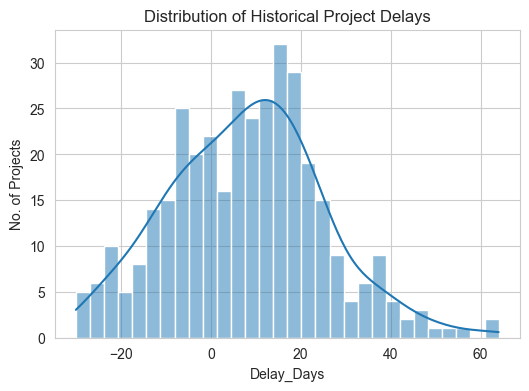

In [35]:
plt.figure(figsize=(6,4))

sns.histplot(
    project_df["Delay_Days"],
    bins=30,
    kde=True
)

plt.title("Distribution of Historical Project Delays")
plt.xlabel("Delay_Days")
plt.ylabel("No. of Projects")

plt.show()

### Distribution of Historical Project Delays

- This chart visualizes the distribution of historical project delays using the `Delay_Days` variable.
- Each bar represents the **number of projects** whose delays fall within a specific range of days.
- **Negative values** indicate projects that finished **earlier than planned**, while **positive values** represent **delayed project completions**.
- Examining this distribution helps identify typical delay patterns in historical project data, including:
  - whether delays are generally **small or large**
  - whether the distribution is **symmetric or skewed**
  - whether **early completions** also occur
- These historical delay patterns serve as the **input distribution for the Monte Carlo simulation**.
- By sampling from this empirical distribution, the simulation generates **realistic scenarios of potential future project completion times under uncertainty**.

## Project-Specific Dependency-Aware Simulation

To make the forecasting workflow more realistic, I now move from a generic portfolio delay simulation to a **project-specific DAG-based simulation**.

Instead of using one fixed duration for an abstract project,:

1. select a representative high-risk project from the portfolio  
2. translate it into a task network with dependencies  
3. simulate uncertainty at the task level  
4. recompute the critical path during each Monte Carlo iteration  

This makes the forecast more useful for realistic planning scenarios.


In [36]:
from pathlib import Path
import pandas as pd
from IPython.display import display

if "DATA_DIR" not in globals():
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / "data").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    DATA_DIR = PROJECT_ROOT / "data"

if "project_df" not in globals():
    project_df = pd.read_csv(DATA_DIR / "project_portfolio_history.csv")

high_risk_projects = project_df[project_df["Outcome_Risk_Level"] == "High"].copy()
reference_delay = high_risk_projects["Delay_Days"].median()
selected_project = high_risk_projects.iloc[
    (high_risk_projects["Delay_Days"] - reference_delay).abs().argsort().iloc[0]
]

planned_duration = float(selected_project["Planned_Duration_Days"])

display(
    selected_project[[
        "Project_ID",
        "Portfolio_Segment",
        "Planning_Mode",
        "Planned_Duration_Days",
        "Actual_Duration_Days",
        "Delay_Days",
        "Outcome_Risk_Level",
    ]].to_frame(name="value")
)


,value
Project_ID,P308
Portfolio_Segment,Energy
Planning_Mode,Manual
Planned_Duration_Days,355
Actual_Duration_Days,394
Delay_Days,39
Outcome_Risk_Level,High


### Selected Project for Dependency-Aware Simulation

- The table shows the **real project selected from our portfolio** to run the DAG-based Monte Carlo simulation.
- Instead of using a generic example, **Project `P308`** is used, which makes the analysis more realistic and relevant to our product.
- The project belongs to the **Energy** portfolio segment and uses **Manual** planning.
- Its **planned duration** was **355 days**, while its **actual duration** was **394 days**.
- This means the project finished **39 days late**, which is why it is labeled as **High risk**.
- This project was chosen because its delay is close to the **median delay of all high-risk projects**, so it represents a typical high-risk case rather than an extreme outlier.
- This gives the next steps in the notebook a **realistic project context** for building the task dependency graph, identifying the critical path, and simulating schedule uncertainty.


In [37]:
import sys
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go

# -----------------------------
# Project setup
# -----------------------------
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from modeling.graph_builder import build_project_graph
from modeling.critical_path import critical_path_by_mean

# -----------------------------
# Data loading
# -----------------------------
if "DATA_DIR" not in globals():
    DATA_DIR = PROJECT_ROOT / "data"

if "project_df" not in globals():
    project_df = pd.read_csv(DATA_DIR / "project_portfolio_history.csv")

if "selected_project" not in globals():
    high_risk_projects = project_df[project_df["Outcome_Risk_Level"] == "High"].copy()
    reference_delay = high_risk_projects["Delay_Days"].median()
    selected_project = high_risk_projects.iloc[
        (high_risk_projects["Delay_Days"] - reference_delay).abs().argsort().iloc[0]
    ]

# -----------------------------
# Convert one project into DAG tasks
# -----------------------------
def project_to_tasks(project_row: pd.Series) -> list[dict]:
    shares = {
        "T1": ("Discovery", 0.08),
        "T2": ("Design", 0.15),
        "T3": ("Procurement", 0.18),
        "T4": ("Site Preparation", 0.12),
        "T5": ("Execution", 0.28),
        "T6": ("QA and Commissioning", 0.12),
        "T7": ("Handover", 0.07),
    }

    dependencies = {
        "T1": [],
        "T2": ["T1"],
        "T3": ["T1"],
        "T4": ["T2"],
        "T5": ["T3", "T4"],
        "T6": ["T5"],
        "T7": ["T6"],
    }

    tasks = []
    for task_id, (task_name, share) in shares.items():
        mean_duration = float(project_row["Planned_Duration_Days"]) * share
        std_dev = mean_duration * 0.15

        tasks.append(
            {
                "id": task_id,
                "name": task_name,
                "dependencies": dependencies[task_id],
                "mean_duration": round(mean_duration, 2),
                "std_dev": round(std_dev, 2),
            }
        )

    return tasks

# -----------------------------
# Build DAG objects used later
# -----------------------------
dag_tasks = project_to_tasks(selected_project)

dag_graph = build_project_graph(dag_tasks)
dag_critical_path, dag_critical_path_mean = critical_path_by_mean(dag_graph)

planned_duration = float(selected_project["Planned_Duration_Days"])

task_frame = pd.DataFrame(dag_tasks).rename(
    columns={
        "id": "Task_ID",
        "name": "Task_Name",
        "dependencies": "Dependencies",
        "mean_duration": "Mean_Duration_Days",
        "std_dev": "Std_Dev_Days",
    }
)

task_frame["Dependencies"] = task_frame["Dependencies"].apply(
    lambda x: ", ".join(x) if x else "Start"
)

print("Selected project:", selected_project["Project_ID"])
print("Planned duration:", round(planned_duration, 1), "days")
print("Critical path:", " -> ".join(dag_critical_path))
print("Critical path mean duration:", round(dag_critical_path_mean, 1), "days")

# -----------------------------
# Fixed DAG layout for plotting
# -----------------------------
pos = {
    "T1": (0, 0),
    "T2": (1, 1),
    "T3": (1, -1),
    "T4": (2, 1),
    "T5": (3, 0),
    "T6": (4, 0),
    "T7": (5, 0),
}

# Edges
edge_x = []
edge_y = []
arrow_annotations = []

for source, target in dag_graph.edges():
    x0, y0 = pos[source]
    x1, y1 = pos[target]

    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

    arrow_annotations.append(
        dict(
            x=x1,
            y=y1,
            ax=x0,
            ay=y0,
            xref="x",
            yref="y",
            axref="x",
            ayref="y",
            showarrow=True,
            arrowhead=3,
            arrowsize=1.2,
            arrowwidth=2,
            arrowcolor="#64748b",
        )
    )

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode="lines",
    line=dict(width=2, color="#94a3b8"),
    hoverinfo="none",
)

# Nodes
node_x = []
node_y = []
node_color = []
node_text = []

for node in dag_graph.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

    if node in dag_critical_path:
        node_color.append("#dc2626")
    else:
        node_color.append("#2563eb")

    task_name = next(task["name"] for task in dag_tasks if task["id"] == node)
    node_text.append(f"{node}: {task_name}")

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers+text",
    text=list(dag_graph.nodes()),
    textposition="top center",
    hovertext=node_text,
    hoverinfo="text",
    marker=dict(
        size=28,
        color=node_color,
        line=dict(width=2, color="white"),
    ),
)

fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title=f"Task Dependency Graph for Project {selected_project['Project_ID']}",
        showlegend=False,
        hovermode="closest",
        margin=dict(b=20, l=20, r=20, t=50),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        annotations=arrow_annotations,
    ),
)

Selected project: P308
Planned duration: 355.0 days
Critical path: T1 -> T2 -> T4 -> T5 -> T6 -> T7
Critical path mean duration: 291.1 days


### Building the Task Dependency Model

- This cell converts the **selected real project** into a simplified set of **7 dependent tasks**.
- Instead of forecasting the project as one single duration, the workflow breaks it into key phases: **T1 – Discovery, T2 – Design, T3 – Procurement, T4 – Site Preparation, T5 – Execution, T6 – QA & Commissioning, and T7 – Handover**.
- Each task is assigned a **dependency structure** so the model reflects the logical sequence of project execution.
- Task durations are derived by allocating the selected project’s **planned duration** across these phases using predefined task shares.
- Task uncertainty is modeled with a simple assumption in which each task receives a **standard deviation equal to 15% of its mean duration**.
- This step produces the **Directed Acyclic Graph (DAG)** structure and identifies the **critical path** used in the following forecasting steps.
- Because the selected project may change when the notebook is re-run, the exact **project ID**, **critical path**, and **critical path mean duration** are shown dynamically in the code output rather than fixed in this markdown.

## Task Dependency Graph

The figure below visualizes the task network as a **Directed Acyclic Graph (DAG)**, where each node represents a task and each arrow represents a dependency between tasks.

In [38]:
fig.show()

## Task Dependency Graph – Interpretation

### Structure of the graph
- The graph is a **Directed Acyclic Graph (DAG)** that represents the execution order of project tasks.
- Each node (**T1–T7**) corresponds to a simplified **project phase**.
- Directed arrows indicate **precedence relationships**, showing which tasks must be completed before others can begin.

### Flow of execution
- The project starts at **T1 (Discovery)**.
- From T1, the workflow splits into two branches:
  - **T1 → T2 (Design)**
  - **T1 → T3 (Procurement)**
- The Design branch continues through:
  - **T2 → T4 (Site Preparation)**
- The workflow then converges at **T5 (Execution)**:
  - **T3 → T5**
  - **T4 → T5**
- Final stages proceed sequentially:
  - **T5 → T6 (QA & Commissioning)**
  - **T6 → T7 (Handover)**

### Critical path
- Nodes highlighted in **red** represent the **critical path**.
- The critical path defines the **longest dependency chain** in the network and therefore the **minimum completion time** under the current assumptions.
- Delays in critical-path tasks directly increase the total project duration.

### Dependency insights
- The graph highlights both:
  - **parallel work opportunities** through the Design and Procurement branches
  - a **synchronization point** at **T5 (Execution)**, where upstream branches must be completed before execution can proceed
- Even tasks outside the critical path remain operationally important because delays in upstream branches may still affect downstream execution.

### Interpretation takeaway
- This visualization makes task dependencies explicit and supports:
  - clearer understanding of execution order
  - identification of bottlenecks
  - better prioritization of schedule-sensitive tasks before simulation

## Run Dependency-Aware Monte Carlo Simulation

Thousands of possible completions for the selected project are simulated by sampling task durations around their estimated means and recalculating the critical path for each iteration.


In [39]:
from analytics.metrics import compute_metrics
from simulation.monte_carlo import run_monte_carlo

# Ensure required objects exist from the DAG-building step
if "dag_graph" not in globals():
    raise NameError("dag_graph is not defined. Run the task dependency model cell first.")

if "dag_critical_path" not in globals():
    raise NameError("dag_critical_path is not defined. Run the task dependency model cell first.")

if "planned_duration" not in globals():
    planned_duration = float(selected_project["Planned_Duration_Days"])

# Run dependency-aware Monte Carlo simulation
simulated_completion_times = run_monte_carlo(
    dag_graph,
    iterations=5000,
    seed=42,
)

# Compute forecast metrics against the planned project duration
dag_metrics = compute_metrics(
    simulated_completion_times,
    deadline_days=planned_duration,
)

p50 = dag_metrics["p50"]
p80 = dag_metrics["p80"]
prob_delay = dag_metrics["delay_probability"]

print("Selected project:", selected_project["Project_ID"])
print("Planned duration:", round(planned_duration, 1), "days")
print("Critical path:", " -> ".join(dag_critical_path))
print("P50 forecast:", round(p50, 1), "days")
print("P80 forecast:", round(p80, 1), "days")
print("Probability of delay:", f"{prob_delay:.2%}")

Selected project: P308
Planned duration: 355.0 days
Critical path: T1 -> T2 -> T4 -> T5 -> T6 -> T7
P50 forecast: 291.5 days
P80 forecast: 308.2 days
Probability of delay: 0.08%


## Dependency-Aware Monte Carlo Forecast Results

- This output shows the **simulation-based schedule forecast** for the selected real project, **P308**.
- The model runs **5,000 Monte Carlo simulations**, each time varying task durations within their uncertainty ranges while respecting task dependencies.
- The reported **planned duration** is **355.0 days**, which is the project’s original schedule baseline from the dataset.
- The **critical path** is **T1 → T2 → T4 → T5 → T6 → T7**, meaning these are the tasks that drive the overall completion date.
- The **P50 forecast** is **291.5 days**. This is the median simulated completion time, meaning the project is expected to finish in about **291.5 days** in 50% of simulated scenarios.
- The **P80 forecast** is **308.2 days**. This is the more conservative planning target, meaning about **80% of simulated outcomes** finish by **308.2 days**.
- Because both **P50** and **P80** are **well below the planned duration of 355.0 days**, the simulation suggests that the project schedule is **comfortably achievable under the current assumptions**.
- The **probability of delay** is **0.08%**, indicating a **very low risk** of finishing later than the planned baseline in the simulated scenarios.
- In practical terms, this suggests that, under the assumptions of this DAG-based model, the selected project has **substantial schedule buffer** relative to its original deadline.
- This result is useful because it converts uncertainty into **decision-making metrics** rather than relying on a single fixed completion estimate.

## Visualize Completion-Time Uncertainty

The distribution below shows how the selected project may complete under repeated simulations of task-level uncertainty.


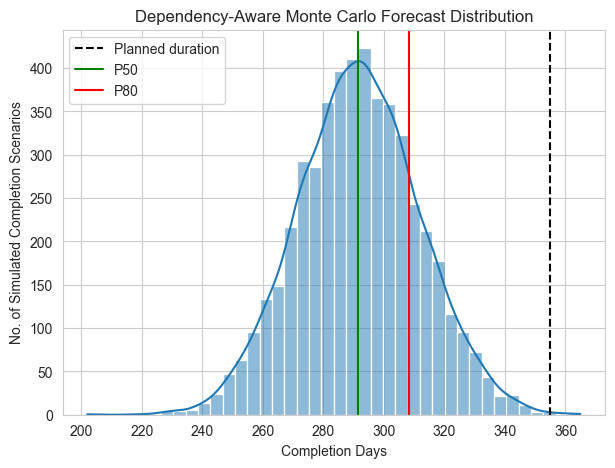

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.histplot(
    simulated_completion_times,
    bins=40,
    kde=True
)

plt.axvline(planned_duration, color="black", linestyle="--", label="Planned duration")
plt.axvline(p50, color="green", label="P50")
plt.axvline(p80, color="red", label="P80")

plt.title("Dependency-Aware Monte Carlo Forecast Distribution")
plt.xlabel("Completion Days")
plt.ylabel("No. of Simulated Completion Scenarios")
plt.legend()
plt.show()

## Completion-Time Distribution for the Selected Project

- This chart shows the **distribution of simulated completion times** for project **P308** after running the dependency-aware Monte Carlo simulation.
- Each bar represents how often a given completion-time range appeared across the simulated scenarios.
- The shape of the histogram helps illustrate the project’s **schedule uncertainty** rather than relying on a single forecast value.
- The **black dashed line** marks the original **planned duration of 355.0 days**.
- The **green line** marks the **P50 forecast (291.5 days)**, which is the median simulated completion time.
- The **red line** marks the **P80 forecast (308.2 days)**, which is the more conservative planning target.
- Because both the **P50** and **P80** lines are clearly to the left of the planned-duration line, the simulation suggests that the project is **comfortably achievable under the current assumptions**.
- The gap between the simulated forecast range and the planned baseline indicates **substantial schedule buffer** relative to the original deadline.
- This visualization is useful because it translates the simulation into an interpretable view of the **spread of possible schedule outcomes**, not just a single completion estimate.

## Probability of Delay

A useful operational metric is the probability that the selected project finishes later than its planned duration.


In [41]:
print("Probability of delay:", round(prob_delay * 100, 2), "%")


Probability of delay: 0.08 %


## Probability of Delay

- This output shows the **estimated probability that the selected project will finish later than its planned duration**.
- A **delay probability of 0.08%** means that in the Monte Carlo simulation, the project finished after the planned deadline in **very few scenarios**.
- In other words, the project is forecasted to finish **on time in almost all simulated cases** under the current assumptions.
- This metric is useful because it converts the full simulation into a simple planning indicator that stakeholders can interpret quickly.
- For the selected project **P308**, the result suggests that the schedule is **comfortably achievable** rather than just marginally feasible.
- From a decision-making perspective, this means the project does **not currently show meaningful schedule pressure** in the simulation, though critical-path tasks should still be monitored because they drive the completion date.

## Supporting DAG Diagnostics

The sections below expose the task-level assumptions and compare the selected project with the risk_monitoring_snapshot.csv.


In [42]:
display(task_frame)


,Task_ID,Task_Name,Dependencies,Mean_Duration_Days,Std_Dev_Days
0,T1,Discovery,Start,28.40,4.26
1,T2,Design,T1,53.25,7.99
2,T3,Procurement,T1,63.90,9.58
3,T4,Site Preparation,T2,42.60,6.39
4,T5,Execution,"T3, T4",99.40,14.91
5,T6,QA and Commissioning,T5,42.60,6.39
6,T7,Handover,T6,24.85,3.73


## Task Table Interpretation

### Purpose of this section
- This section validates the **task structure used to build the DAG**.
- It ensures that all tasks, durations, and dependencies are correctly defined before simulation and visualization.


### What the table represents
- Each row corresponds to a **project task (T1–T7)**.
- The table provides a structured view of:
  - **Task ID** (T1–T7)
  - **Task name**
  - **Dependencies** (preceding tasks)
  - **Mean duration** (expected time)
  - **Standard deviation** (uncertainty in duration)


### Dependency validation
- The table confirms the intended dependency logic:
  - T1 is the starting task (no dependencies)
  - T2 and T3 depend on T1 (parallel paths)
  - T4 depends on T2
  - T5 depends on both T3 and T4 (merge point)
  - T6 depends on T5
  - T7 depends on T6

- This structure ensures the graph remains a **valid DAG (no cycles)**.


### Why this matters
- Correct dependencies are critical for:
  - **Accurate critical path calculation**
  - **Reliable Monte Carlo simulation**
  - **Valid schedule risk estimation**

- Any error here would propagate into:
  - Incorrect timelines
  - Misleading risk forecasts


### Diagnostic takeaway
- The table acts as a **sanity check layer** between:
  - Data preparation  
  - Graph construction  
  - Simulation and forecasting

- It provides transparency into how the **project model is constructed internally.**


## Comparison with `risk_monitoring_snapshot.csv`

This provides a reference point between the project-specific DAG forecast and the existing advisory monitoring output.


In [43]:
# Ensure monitoring dataset is loaded
if "monitoring_df" not in globals():
    monitoring_df = pd.read_csv(DATA_DIR / "risk_monitoring_snapshot.csv")

# Slice monitoring data for selected project
monitoring_slice = monitoring_df.loc[
    monitoring_df["Project_ID"] == selected_project["Project_ID"],
    [
        "Snapshot_Month",
        "Project_ID",
        "Predicted_Risk_Level",
        "Actual_Risk_Level",
        "Prediction_Confidence",
        "P80_Forecast_Days",
        "Actual_Completion_Days",
        "Absolute_Forecast_Error_Days",
    ],
]

display(monitoring_slice)

,Snapshot_Month,Project_ID,Predicted_Risk_Level,Actual_Risk_Level,Prediction_Confidence,P80_Forecast_Days,Actual_Completion_Days,Absolute_Forecast_Error_Days
167,2025-12-01,P308,Medium,High,0.701,408,394,14


### Comparison with `risk_monitoring_snapshot.csv`

- This output shows the **monitoring record for the same selected project, P308**, to compare the DAG-based forecast with the repository’s existing monitoring snapshot.
- The snapshot month is **December 2025 (`2025-12-01`)**, meaning this is the monitoring view captured for that project at that point in time.
- The monitoring system predicted the project’s risk level as **Medium**, while the actual recorded risk level was **High**.
- This means the monitoring snapshot **underestimated the project’s true risk** for **P308**.
- The prediction confidence is **0.701**, which means the model was fairly confident, even though the final risk label was not fully correct.
- The monitoring system’s **P80 forecast** was **408 days**, while the project’s **actual completion** was **394 days**.
- This means the monitoring forecast was **14 days later than reality**, which is why the **absolute forecast error** is **14 days**.
- In practical terms, this table provides a useful benchmark:
  - the monitoring system was directionally cautious on schedule
  - but it was less accurate on the final risk label
- This comparison helps show why the notebook’s **project-specific DAG and Monte Carlo forecast** is useful: it provides a second, project-level view of schedule risk rather than relying only on the monitoring snapshot.

In [44]:
dag_summary = pd.DataFrame(
    {
        "Metric": [
            "Selected project",
            "Critical path",
            "Planned duration",
            "DAG mean duration",
            "DAG P50",
            "DAG P80",
            "DAG delay probability",
        ],
        "Value": [
            selected_project["Project_ID"],
            " -> ".join(dag_critical_path),
            f"{int(planned_duration)} days",
            f"{dag_critical_path_mean:.1f} days",
            f"{p50:.1f} days",
            f"{p80:.1f} days",
            f"{prob_delay:.1%}",
        ],
    }
)

display(dag_summary)


,Metric,Value
0,Selected project,P308
1,Critical path,T1 -> T2 -> T4 -> T5 -> T6 -> T7
2,Planned duration,355 days
3,DAG mean duration,291.1 days
4,DAG P50,291.5 days
5,DAG P80,308.2 days
6,DAG delay probability,0.1%


## Summary Table for the Selected Project

- This table brings together the **most important forecasting results** for the selected project, **P308**, in one place.
- It acts as a **high-level project summary**, combining the main outputs from the DAG model and Monte Carlo simulation.

### What each row means

- **Selected project: P308**  
  This confirms which real project from the portfolio is being analyzed.

- **Critical path: T1 → T2 → T4 → T5 → T6 → T7**  
  These are the tasks that most directly determine the final completion date. Delays in these tasks have the greatest impact on the overall schedule.

- **Planned duration: 355 days**  
  This is the original schedule baseline from the dataset.

- **DAG mean duration: 291.1 days**  
  This is the expected project duration based on the average task durations along the dependency-aware structure.

- **DAG P50: 291.5 days**  
  This is the median simulated completion time. About half of the simulated project outcomes finish before this point.

- **DAG P80: 308.2 days**  
  This is the more conservative forecast target. About 80% of simulated outcomes finish before this duration.

- **DAG delay probability: 0.1%**  
  This is the estimated probability that the project finishes later than its planned duration of 355 days.

### Why this table matters

- The table turns the full simulation into a **decision-ready summary**.
- It makes it easier to compare:
  - the original plan
  - the expected DAG-based duration
  - the risk-adjusted forecast
  - the probability of schedule overrun
- For this project, the results suggest that the plan is **comfortably achievable under the current assumptions**, with a **very low risk of delay**, although the critical path should still be monitored because it drives the project finish date.

In [45]:
display(pd.DataFrame({"critical_path_task": dag_critical_path}))

,critical_path_task
0,T1
1,T2
2,T4
3,T5
4,T6
5,T7


## Critical Path Tasks

- This table lists the tasks that make up the **critical path** for the selected project.
- The critical path is the sequence of tasks that has the **greatest influence on the final project completion date**.
- For project **P308**, the critical path tasks are:
  - **T1**
  - **T2**
  - **T4**
  - **T5**
  - **T6**
  - **T7**

### What this means

- These tasks are the **most schedule-sensitive activities** in the DAG.
- If any of these tasks take longer than expected, the **overall project completion date is also likely to move later**.
- The only task not shown here is **T3**, which means it is **not on the critical path** under the current simulation assumptions.
- This does not mean **T3** is unimportant; it simply has **more scheduling flexibility** than the tasks listed in the table.

### Why this table matters

- It helps identify where project managers should focus the most attention.
- It supports better decision-making by showing which tasks are the **main drivers of schedule risk**.
- In practical terms, this table highlights where delays are most likely to affect the final delivery date.

## Key Insights & Takeaways

This notebook provides several important planning insights:

- **Project-specific forecasts** are more useful than generic fixed-duration simulations because they reflect the structure and assumptions of a real selected project.
- **P50 and P80 estimates** help teams distinguish between a likely delivery outcome and a more conservative planning target.
- **DAG modeling** captures dependency propagation, making the critical path visible and operationally relevant for schedule analysis.
- Comparing the **DAG-based forecast** with the **monitoring snapshot** creates a stronger bridge between analytical results and decision support.
- Within the current repository, this notebook presents a more realistic **end-to-end forecasting workflow** using the available data and utilities.

Overall, the results show how dependency-aware simulation can turn project data into more interpretable and decision-ready schedule forecasts.